<center>

### CS-GY 9223: Intro To Responsible AI

### Fairness Audit of Student Performance Prediction Model
</center>

<center>

Laxman Singh Rawat      |       Nikhil Mahana       |       Yathin Reddy Duvuru

</center>

## Background

This project aims to audit the fairness of the Student Performance Prediction Model. This work builds upon the analysis of a dataset concerning the performance of students from two Portuguese secondary schools, originally conducted by Mohamed Salah Ibrahim, a Data Scientist & AI Engineer [3].

In his work, Ibrahim developed a predictive model that estimates a student's final grade based on various factors, including demographics, parental education, study time, travel time, and family relationships. While his study covers data exploration, feature preprocessing, and model evaluation, it does not assess the model's fairness regarding sensitive features such as age, sex, parental education, and profession.

The motivation to conduct these fairness analyses and identify the potential impacts of using such an Automated Decision System (ADS) to score students, drawing parallels to the controversy surrounding the UK's grading algorithm during the COVID-19 pandemic in 2020 [2]. We will measure key bias metrics—such as demographic parity, equalized odds, and predictive parity—across these sensitive attributes. Our goal is to understand the trade-offs between different fairness definitions.

## Input

#### Dataoverview

The data used in this project is downloaded from UC Irvine's Machine Learning Repository [4] and holds information about student in secondary education of two Portuguese schools. The data attributes include student grades, demographic, social and school related features and it was collected by using school reports and questionnaires. Two datasets are provided regarding the performance in two distinct subjects: Mathematics (mat) and Portuguese language (por).[1]

The dataset contains information on students’ demographic and academic attributes such as:
- Student demographics (`sex`, `age`, `address`)
- Parental education levels (`Medu`, `Fedu`)  
- Study and travel times (`studytime`, `traveltime`)  
- Family and social relationships (`Pstatus`, `famrel`, `goout`, `romantic`)  
- Academic performance indicators (`G1`, `G2`, `failures`, `activities`)  
- Lifestyle factors (`Dalc`, `Walc`, `health`, `absences`)

Following is the table containing all the attributes with their description and data type.

| Attribute | Description | Domain |
|-----------|-------------|---------|
| **sex** | Student's sex | Binary: female or male |
| **age** | Student's age | Numeric: from 15 to 22 |
| **school** | Student's school | Binary: Gabriel Pereira or Mousinho da Silveira |
| **address** | Student's home address type | Binary: urban or rural |
| **Pstatus** | Parent's cohabitation status | Binary: living together or apart |
| **Medu** | Mother's education | Numeric: from 0 to 4ᵃ |
| **Mjob** | Mother's job | Nominalᵇ |
| **Fedu** | Father's education | Numeric: from 0 to 4ᵃ |
| **Fjob** | Father's job | Nominalᵇ |
| **guardian** | Student's guardian | Nominal: mother, father or other |
| **famsize** | Family size | Binary: ≤ 3 or > 3 |
| **famrel** | Quality of family relationships | Numeric: from 1 (very bad) to 5 (excellent) |
| **reason** | Reason to choose this school | Nominal: close to home, school reputation, course preference or other |
| **traveltime** | Home to school travel time | Numeric: 1 (< 15 min.), 2 (15 to 30 min.), 3 (30 min. to 1 hour) or 4 (> 1 hour) |
| **studytime** | Weekly study time | Numeric: 1 (< 2 hours), 2 (2 to 5 hours), 3 (5 to 10 hours) or 4 (> 10 hours) |
| **failures** | Number of past class failures | Numeric: n if 1 ≤ n < 3, else 4 |
| **schoolsup** | Extra educational school support | Binary: yes or no |
| **famsup** | Family educational support | Binary: yes or no |
| **activities** | Extra-curricular activities | Binary: yes or no |
| **paidclass** | Extra paid classes | Binary: yes or no |
| **internet** | Internet access at home | Binary: yes or no |
| **nursery** | Attended nursery school | Binary: yes or no |
| **higher** | Wants to take higher education | Binary: yes or no |
| **romantic** | With a romantic relationship | Binary: yes or no |
| **freetime** | Free time after school | Numeric: from 1 (very low) to 5 (very high) |
| **goout** | Going out with friends | Numeric: from 1 (very low) to 5 (very high) |
| **Walc** | Weekend alcohol consumption | Numeric: from 1 (very low) to 5 (very high) |
| **Dalc** | Workday alcohol consumption | Numeric: from 1 (very low) to 5 (very high) |
| **health** | Current health status | Numeric: from 1 (very bad) to 5 (very good) |
| **absences** | Number of school absences | Numeric: from 0 to 93 |
| **G1** | First period grade | Numeric: from 0 to 20 |
| **G2** | Second period grade | Numeric: from 0 to 20 |
| **G3** | Final grade | Numeric: from 0 to 20 |

**Notes:**
- ᵃ Education levels: 0 (none), 1 (primary education - 4th grade), 2 (5th to 9th grade), 3 (secondary education), 4 (higher education)
- ᵇ Nominal job categories include: teacher, health care related, civil services, at_home, or other

### Data Profiling

#### Import Libraries and Dependencies

In [94]:
# Data manipulation and numerical computing
import matplotlib.pyplot as plt  # For creating static, animated, and interactive visualizations in Python
import matplotlib.ticker as ticker  # For formatting the ticks on the axes of plots
import seaborn as sn  # For statistical data visualization based on matplotlib
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computing and handling arrays

# Machine learning - model training and evaluation
from sklearn.model_selection import train_test_split  # For splitting data into training and testing sets
from sklearn.preprocessing import StandardScaler  # For standardizing features by removing the mean and scaling to unit variance
from sklearn.linear_model import LogisticRegression  # For logistic regression modeling
import sklearn.metrics as skm  # For evaluating the performance of machine learning models
from sklearn.model_selection import cross_val_score  # For cross-validation of models
from sklearn.metrics import confusion_matrix  # For computing confusion matrix to evaluate accuracy of a classification

# Fairness evaluation metrics
from fairlearn.metrics import MetricFrame  # For creating a frame of metrics for fairness evaluation
from fairlearn.metrics import demographic_parity_difference, demographic_parity_ratio, selection_rate  # For measuring demographic parity
from fairlearn.metrics import false_negative_rate, false_positive_rate  # For measuring false negative and positive rates
from fairlearn.preprocessing import CorrelationRemover # For removing correlations with sensitive features
from fairlearn.reductions import ExponentiatedGradient # For fairness-aware model training
from fairlearn.reductions import GridSearch # For fairness-aware model training using grid search
from fairlearn.reductions import DemographicParity, ErrorRate # For fairness constraints
from fairlearn.postprocessing import ThresholdOptimizer  # For post-processing to achieve fairness


# Data fetching and utilities
from ucimlrepo import fetch_ucirepo  # For accessing datasets from the UCI Machine Learning Repository
from IPython.display import clear_output  # For clearing the output of the current cell

# Disable warnings for cleaner output
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import math

#### Fetch Dataset from UCI Repository

In [95]:
# Fetch the student performance dataset from UCI ML Repository
student_performance = fetch_ucirepo(id=320) 

# Get Full Dataset for Analysis
full_df = student_performance.data.original
full_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


#### Dataset Shape and Structure

In [96]:
# Display dimensions of the dataset
full_df.shape

(649, 33)

#### Checking for NULLs and Data Types

In [97]:
# Check for missing values and data types in the dataset
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

There are a total of 649 records and 32 columns in the table. All the columns already have data in categorical or numberical values and there no nulls present that needs to be imputated. 

#### Identify Numeric and Categorical Columns

In [98]:
# Separate columns by data type for appropriate processing
num_cols = full_df.select_dtypes(include='int64').columns
cat_cols = full_df.select_dtypes(include='object').columns
print(f'Numerical columns: {num_cols}')
print(f'Categorical columns: {cat_cols}')


Numerical columns: Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')
Categorical columns: Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')


#### Map Categorical Variables to Meaningful Labels

In [99]:
# Define mappings for categorical and ordinal variables to human-readable format
edu_map = {
    0: "none",
    1: "primary (4th grade)",
    2: "5th to 9th grade",
    3: "secondary",
    4: "higher education"
}

traveltime_map = {
    1: "<15 min",
    2: "15–30 min",
    3: "30 min–1 hour",
    4: ">1 hour"
}

studytime_map = {
    1: "<2 hours",
    2: "2–5 hours",
    3: "5–10 hours",
    4: ">10 hours"
}

school_map = {
    'GP': 'Gabriel Pereira',
    'MS': 'Mousinho da Silveira'
}

address_map = {
    'U': 'urban',
    'R': 'rural'
}

famsize_map = {
    'GT3': 'greater than 3',
    'LE3': 'less or equal to 3'
}

Pstatus_map = {'T': 'living together',
               'A': 'apart'
}

# Apply mappings to transform categorical columns
full_df["Medu"] = full_df["Medu"].map(edu_map)
full_df["Fedu"] = full_df["Fedu"].map(edu_map)
full_df["traveltime"] = full_df["traveltime"].map(traveltime_map)
full_df["studytime"] = full_df["studytime"].map(studytime_map)
full_df['school'] = full_df['school'].map(school_map)
full_df['address'] = full_df['address'].map(address_map)
full_df['famsize'] = full_df['famsize'].map(famsize_map)
full_df['Pstatus'] = full_df['Pstatus'].map(Pstatus_map)

# Display transformed categorical data
full_df[cat_cols].head()

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,Gabriel Pereira,F,urban,greater than 3,apart,at_home,teacher,course,mother,yes,no,no,no,yes,yes,no,no
1,Gabriel Pereira,F,urban,greater than 3,living together,at_home,other,course,father,no,yes,no,no,no,yes,yes,no
2,Gabriel Pereira,F,urban,less or equal to 3,living together,at_home,other,other,mother,yes,no,no,no,yes,yes,yes,no
3,Gabriel Pereira,F,urban,greater than 3,living together,health,services,home,mother,no,yes,no,yes,yes,yes,yes,yes
4,Gabriel Pereira,F,urban,greater than 3,living together,other,other,home,father,no,yes,no,no,yes,yes,no,no


#### Analyzing Categorical Features Distribution

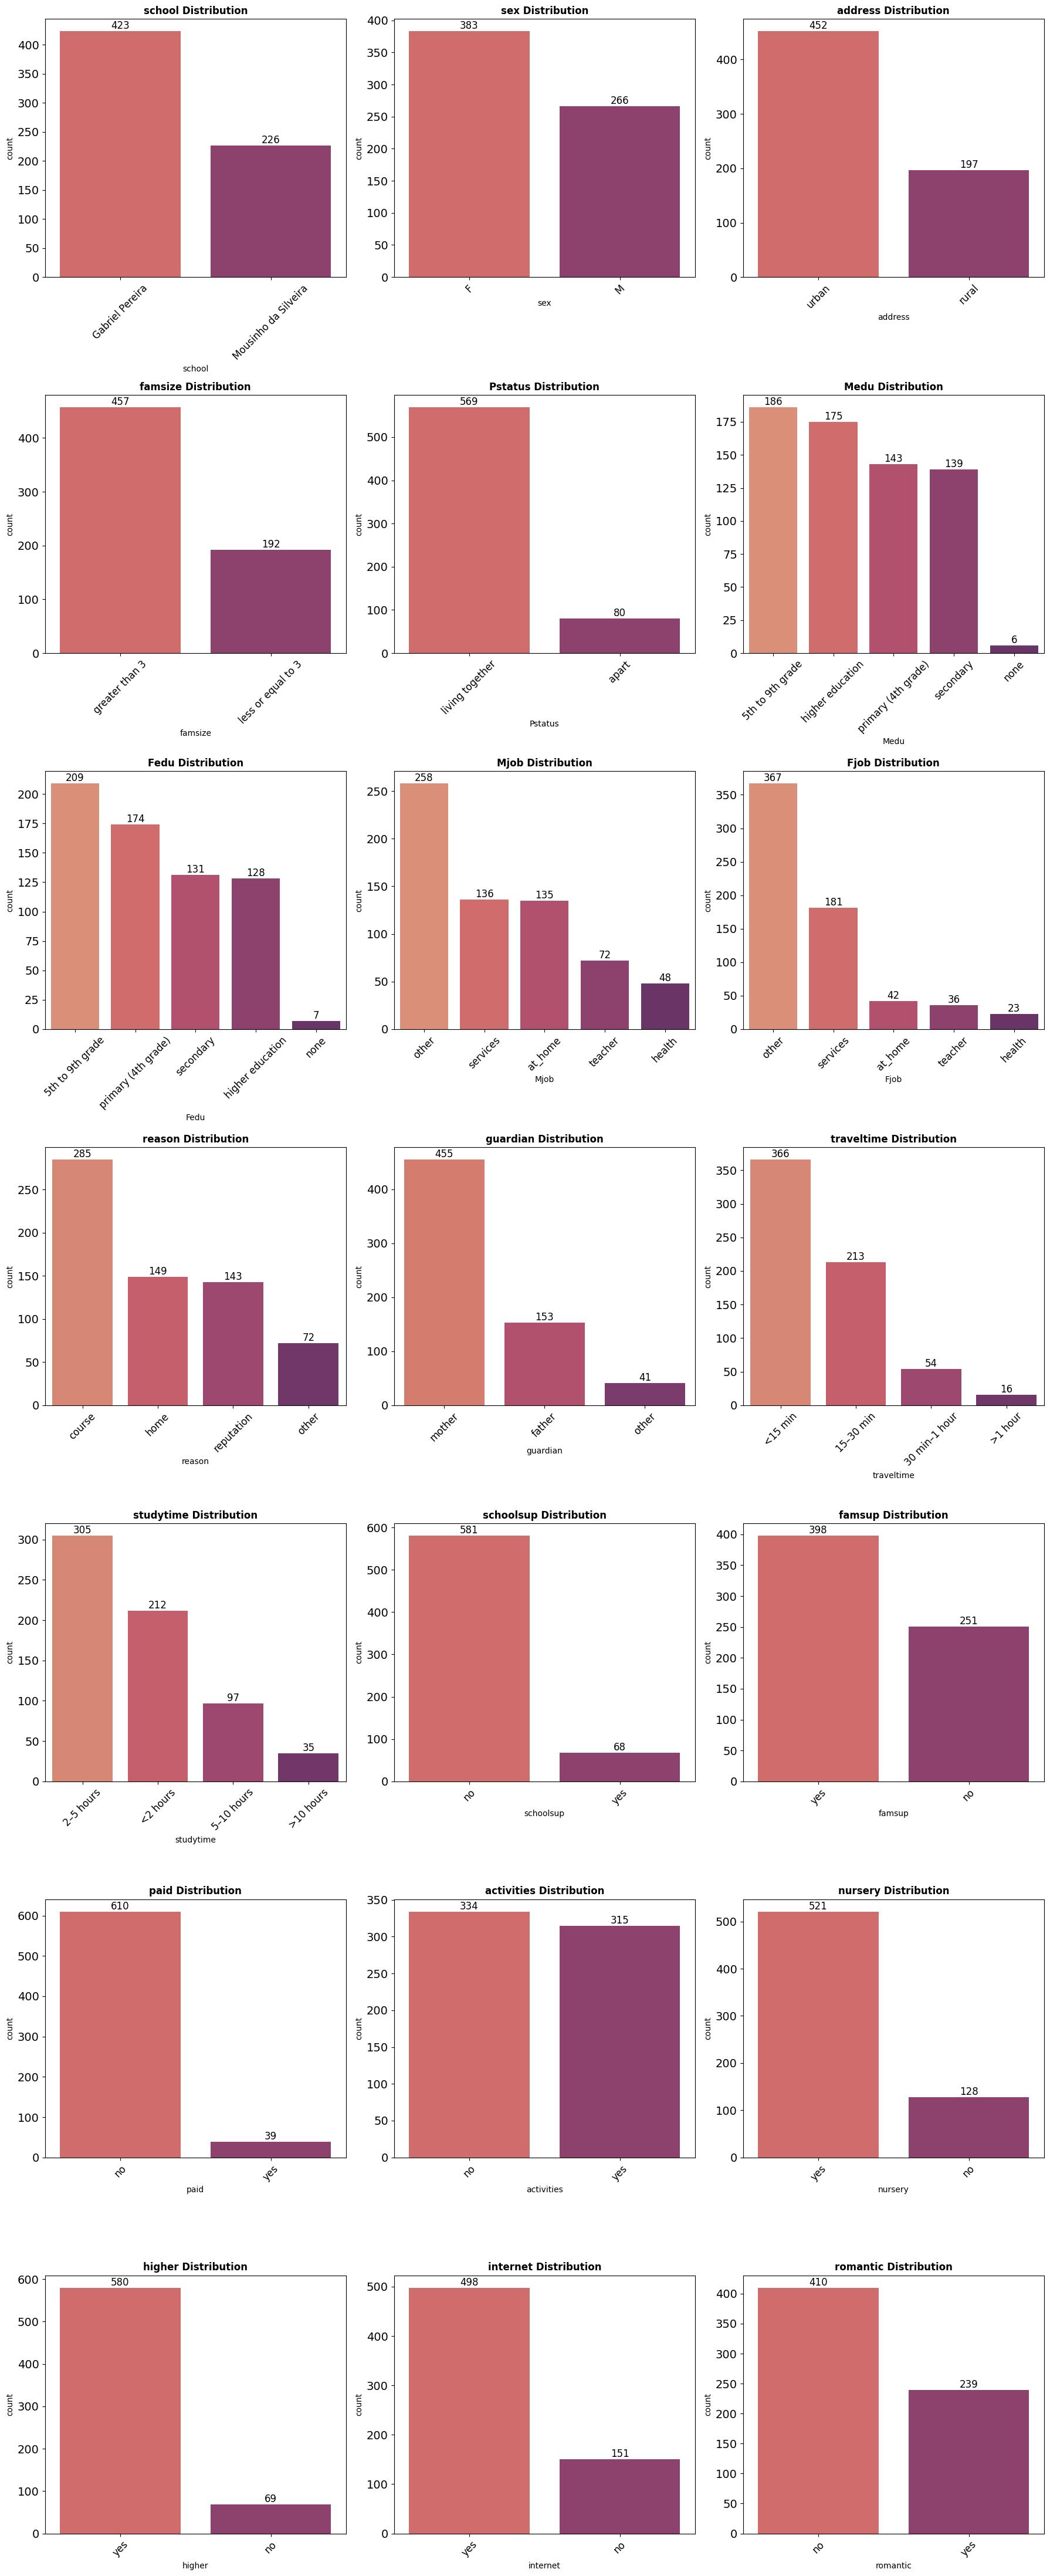

In [100]:
# Re-identify categorical columns after transformation
num_cols = full_df.select_dtypes(include='int64').columns
cat_cols = full_df.select_dtypes(include='object').columns

# Create bar charts for all categorical variables
fig, axes = plt.subplots(7, 3, figsize=(18, 44))
axes = axes.flatten()

for i, col_name in enumerate(cat_cols):
    ax = axes[i]
    sn.countplot(data=full_df, x=col_name, ax=ax, palette="flare", order=full_df[col_name].value_counts().index)
    ax.set_title(f"{col_name} Distribution", fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=12)
    ax.tick_params(axis='y', labelsize=14)
    
    # Add count labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=12)

# Remove unused subplots
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### Discussion on Visual Analysis of Categorical Features

From the bar plots above, it can be stated that the dataset suffers from pre-existing bias. Specifically, Rural students, students not seeking higher education, and students with separated parents are underrepresented as one category dominates in count over the others. When training a model (and subsequently auditing it for bias), class imbalance in categorical features can lead to poor performance on the minority groups.

#### Visualize Numerical Features Distribution

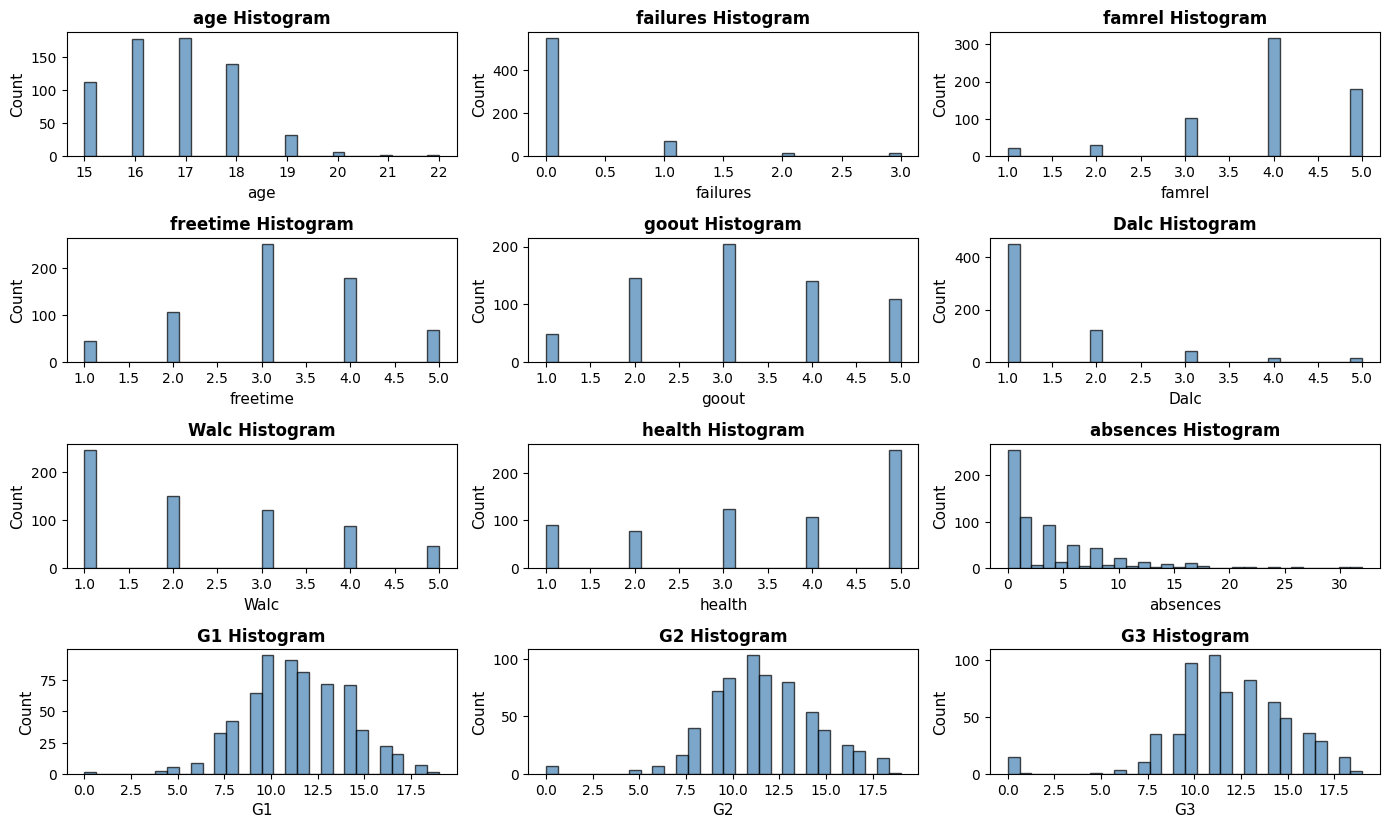

In [101]:
# Create histograms for all numerical features
fig, axes = plt.subplots(5, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(full_df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f"{col} Histogram", fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.tick_params(axis='both', labelsize=10)

# Remove unused subplots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### Discussion on Visual Analysis of Numerical Features

The histograms informs that while academic performance (G1,G2, and G3) generally follows a normal distribution, there is a critical anomaly of 0 score in the final term that might be speculated to represent dropouts from the school rather than poor performers. In contrast, self reported features such as health, and family relations are highly left-skewed which might also impact the learning of the model. 

#### Correlation Analysis of Numerical Features

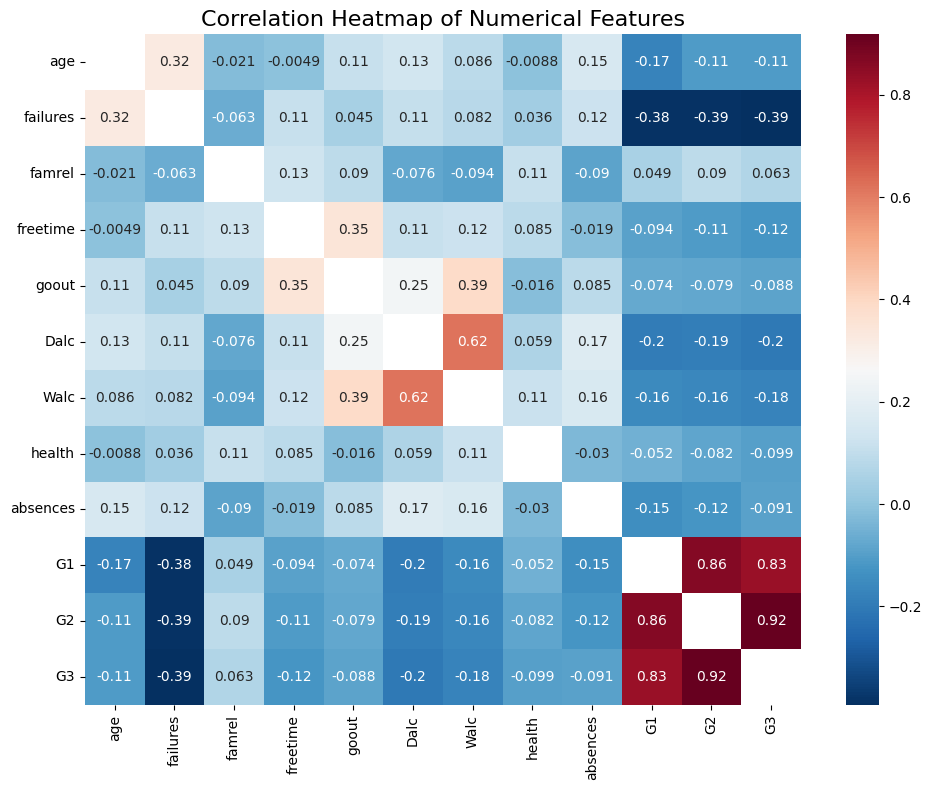

In [102]:
# Compute correlation matrix for numerical features
corr = full_df[num_cols].corr()

# Visualize correlations with heatmap
plt.figure(figsize=(10, 8))
sn.heatmap(full_df[num_cols].corr(), mask=np.identity(len(full_df[num_cols].corr())), annot=True, cmap='RdBu_r')

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

##### Discussion on Correlation Analysis - 

- The strongest correlations are between G1, G2, and G3 (up to 0.92). Past grades are the single best predictor of future grades. Since G1 and G2 are included in the model we are auditing, they likely overpower all other demographic or sensitive features, potentially masking bias (or simply measuring consistency rather than "prediction").

- Failures shows the strongest negative correlation with final grades (approx. -0.39). Students who failed previously are heavily penalized. Crucially, failures is positively correlated with age (0.32). This implies a structural bias: older students are statistically more likely to have past failures, meaning the model will systematically predict lower grades for older students.
    
- There is a logical cluster between Dalc (workday alcohol), Walc (weekend alcohol), and goout (going out), which are all positively correlated. While these features correlate with each other, their direct negative correlation with G3 (grades) is weaker than that of failures. This suggests that while social habits matter, academic history remains the dominant factor in this dataset. 

## Output

In [103]:
#Import Required SKLearn Libraries
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split


In [104]:
#Get Features and Targets
X = full_df.drop(columns = ['G3'])
y = full_df['G3']

In [105]:
#View Features
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    object
 7   Fedu        649 non-null    object
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    object
 13  studytime   649 non-null    object
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [106]:
#View Targets
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 649 entries, 0 to 648
Series name: G3
Non-Null Count  Dtype
--------------  -----
649 non-null    int64
dtypes: int64(1)
memory usage: 5.2 KB


In [107]:
#Get The Numerical and Categorical Columns for Encoding

num_cols = X.select_dtypes(include='int64').columns
cat_cols = X.select_dtypes(include='object').columns

print(len(num_cols) + len(cat_cols)) #Verify All Features Are Accounted For

32


In [108]:
#Get The Binary Columns

binary_cols = []
non_binary_cols = []
for col in cat_cols:
    if len(full_df[col].value_counts().index.to_list()) <= 2:
        binary_cols.append(col)
    else:
        non_binary_cols.append(col)

print(f"Binary Columns: {binary_cols}")
print(f"Non Binary Columns: {non_binary_cols}")


Binary Columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Non Binary Columns: ['Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime']


In [109]:
encoders = {}

for col in binary_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))

In [110]:
encoders

{'school': {'Gabriel Pereira': np.int64(0),
  'Mousinho da Silveira': np.int64(1)},
 'sex': {'F': np.int64(0), 'M': np.int64(1)},
 'address': {'rural': np.int64(0), 'urban': np.int64(1)},
 'famsize': {'greater than 3': np.int64(0), 'less or equal to 3': np.int64(1)},
 'Pstatus': {'apart': np.int64(0), 'living together': np.int64(1)},
 'schoolsup': {'no': np.int64(0), 'yes': np.int64(1)},
 'famsup': {'no': np.int64(0), 'yes': np.int64(1)},
 'paid': {'no': np.int64(0), 'yes': np.int64(1)},
 'activities': {'no': np.int64(0), 'yes': np.int64(1)},
 'nursery': {'no': np.int64(0), 'yes': np.int64(1)},
 'higher': {'no': np.int64(0), 'yes': np.int64(1)},
 'internet': {'no': np.int64(0), 'yes': np.int64(1)},
 'romantic': {'no': np.int64(0), 'yes': np.int64(1)}}

In [111]:
X.select_dtypes(include = 'object').columns.to_list()
#Perform One Hot Encoding Of Categorical (Non-Binary) Features
import pandas as pd

X = pd.get_dummies(
    X,
    columns= X.select_dtypes(include = 'object').columns.to_list(),
    drop_first=False
                  )


print(f"Columns of X: {X.columns}")
print(f"Shape Of X: {X.shape}")

Columns of X: Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'failures',
       'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher',
       'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc',
       'health', 'absences', 'G1', 'G2', 'Medu_5th to 9th grade',
       'Medu_higher education', 'Medu_none', 'Medu_primary (4th grade)',
       'Medu_secondary', 'Fedu_5th to 9th grade', 'Fedu_higher education',
       'Fedu_none', 'Fedu_primary (4th grade)', 'Fedu_secondary',
       'Mjob_at_home', 'Mjob_health', 'Mjob_other', 'Mjob_services',
       'Mjob_teacher', 'Fjob_at_home', 'Fjob_health', 'Fjob_other',
       'Fjob_services', 'Fjob_teacher', 'reason_course', 'reason_home',
       'reason_other', 'reason_reputation', 'guardian_father',
       'guardian_mother', 'guardian_other', 'traveltime_15–30 min',
       'traveltime_30 min–1 hour', 'traveltime_<15 min', 'traveltime_>1 hour',
       'studytime_2–5 hours', 'studytime_5–10 hours', 'study

In [112]:
#Split Into Train and Test Sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [113]:
# Load The Model From The Pickle File

import joblib 
from sklearn.linear_model import Lasso 

file_path = 'model_files/Lasso_model.pkl'

try:
    lasso_model = joblib.load(file_path)
    
    print(f"Loaded Model from '{file_path}'!")
    print(f"Model Type: {type(lasso_model)}")
    print(f"Model coefficients (Head): {lasso_model.coef_[:5]}...")
    
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred during loading: {e}")

Loaded Model from 'model_files/Lasso_model.pkl'!
Model Type: <class 'sklearn.linear_model._coordinate_descent.Lasso'>
Model coefficients (Head): [-0. -0. -0.  0.  0.]...


In [114]:
#Predict

y_pred_LA = lasso_model.predict(X_test)

In [115]:
y_pred_LA[:5]  # Display first 5 predictions

array([18.05152396, 11.37273589, 18.16524022, 11.25901962, 11.60016842])

In [116]:
#Get Performance Metrics

r2_LA = r2_score(y_test, y_pred_LA)
mse_LA = mean_squared_error(y_test, y_pred_LA)
mae_LA = mean_absolute_error(y_test, y_pred_LA)


print("R² Score:", r2_LA)
print("MSE:", mse_LA)
print('MAE:', mae_LA)

R² Score: 0.8694347846173793
MSE: 1.2732348967998475
MAE: 0.6836226646569573


### Output of The System:

The output of the system is a continous values since we are performing a regression task using the Lasso Regressor (Linear Regressor with L1 Regularization) to predict the G3 score of a student based on the features we have. It is an absolute prediction (does not involve probabilities), meaning the output that the model produces for an input sample is the G3 score that the model predicts for that individual based on patterns it has learned between the input features and the G3 scores in the training data. 

Above, we have plotted the $R^2$ Score, MSE (Mean Squared Error) and (MAE) Mean Absolute Error which are some common performance metrics for regression tasks. These metrics indicate the perfomance of the model on the test data that it was run on (for the training data it was trained on)

### Conversion from Regression to a Classification Problem

To assess the fairness of our exam score prediction model, we converted the regression problem into a binary classification task by introducing a threshold-based pass/fail criterion. 
While our model predicts continuous exam scores, most established fairness metrics such as demographic parity, equal opportunity, and equalized odds are designed for classification problems. 
Moreover, in practical educational contexts, the critical decision point is often whether a student passes or fails rather than their exact score. By applying a threshold (11 marks or above for passing), we can evaluate whether the model exhibits bias in predicting passing outcomes across different demographic groups. 

In [117]:
def apply_threshold(scores, threshold):
    """Convert regression scores to binary classification"""
    return (scores >= threshold).astype(int)

In [140]:
#Define the threshold to split the G3 score into Pass/Fail categories
threshold = 10

#Apply the threshold to convert the continous G3 scores into Pass/Fail Categories
y_test_binary = apply_threshold(y_test, threshold)
y_pred_binary = apply_threshold(y_pred_LA, threshold)

In [141]:
def fairness_report(sensitive, feature_name=None, group_labels=None):
    """Compute demographic parity metrics and plot MetricFrame for a sensitive feature.

    sensitive: pd.Series (from X_test)
    feature_name: optional display name (str)
    group_labels: optional dict mapping values -> labels (e.g., {0:'female',1:'male'})
    """
    name = feature_name or (sensitive.name if hasattr(sensitive, 'name') else 'sensitive')

    # Demographic parity summary (uses raw values from the series)
    dp_diff = demographic_parity_difference(y_test_binary, y_pred_binary, sensitive_features=sensitive)
    dp_ratio = demographic_parity_ratio(y_test_binary, y_pred_binary, sensitive_features=sensitive)
    print(f"Demographic parity difference: {dp_diff:.4f}")
    print(f"Demographic parity ratio: {dp_ratio:.4f}")

    # Print selection rates per group/value
    values = sorted(list(sensitive.unique()))
    for v in values:
        label = group_labels.get(v, v) if group_labels else v
        try:
            sr = selection_rate(y_test_binary[sensitive == v], y_pred_binary[sensitive == v])
        except Exception:
            sr = float('nan')
        print(f"{label} selection rate: {sr:.4f}")

    # Prepare a displayable sensitive feature (apply labels if provided)
    s_feature = sensitive.replace(group_labels) if group_labels else sensitive

    # Plot MetricFrame for common metrics
    metrics = {
        'accuracy': skm.accuracy_score,
        'selection_rate': selection_rate,
        'FNR': false_negative_rate,
        'FPR': false_positive_rate
    }

    mf = MetricFrame(metrics=metrics, y_true=y_test_binary, y_pred=y_pred_binary, sensitive_features=s_feature)
    mf.by_group.plot.bar(subplots=True, figsize=(5, 10), ylim=[0, 1], title=f"Metrics by {name}")
    plt.show()

In [142]:
def calculate_metrics(y_true, y_pred, group_name="Overall"):

    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate metrics
    metrics = {
        'group': group_name,
        'n': len(y_true),
        'positive_rate': y_pred.mean(), 
        'true_positive_rate': tp / (tp + fn) if (tp + fn) > 0 else 0, 
        'false_positive_rate': fp / (fp + tn) if (fp + tn) > 0 else 0,  
        'true_negative_rate': tn / (tn + fp) if (tn + fp) > 0 else 0, 
        'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'accuracy': (tp + tn) / len(y_true),
        'base_rate': y_true.mean() 
    }
    
    return metrics


def print_metrics(metrics):
    print(f"\n{metrics['group']} (n={metrics['n']}):")
    print(f"  Accuracy: {metrics['accuracy']:.3f}")
    print(f"  Precision: {metrics['precision']:.3f}")
    print(f"  Base Rate: {metrics['base_rate']:.3f}")
    print(f"  Positive Prediction Rate: {metrics['positive_rate']:.3f}")
    print(f"  True Positive Rate (TPR): {metrics['true_positive_rate']:.3f}")
    print(f"  False Positive Rate (FPR): {metrics['false_positive_rate']:.3f}")


def calculate_subgroup_metrics(y_test, y_pred, subgroup_col):
    
    # Convert to pandas Series for easier grouping
    if not isinstance(subgroup_col, pd.Series):
        subgroup_col = pd.Series(subgroup_col)
    
    results = {}
    
    
    # Calculate metrics for each subgroup
    for group_value in subgroup_col.unique():
        print(f"\nColumn Value: {group_value}")
        mask = subgroup_col == group_value
        group_metrics = calculate_metrics(
            y_test[mask], 
            y_pred[mask], 
            f"Group: {group_value}"
        )
        results[group_value] = group_metrics
        print_metrics(group_metrics)
    
    return results

In [143]:
#@markdown Functions for Fairness Metrics
# metrics for metricframe
from sklearn.metrics import accuracy_score, precision_score, recall_score
from fairlearn.metrics import (demographic_parity_difference, demographic_parity_ratio,
                               selection_rate_difference, false_negative_rate_difference,
                               false_positive_rate_difference, equalized_odds_ratio,
                               false_negative_rate, false_positive_rate)
                               
metrics = {'accuracy': accuracy_score,
           'precision': precision_score,
           'recall': recall_score,
           'FNR': false_negative_rate,
           'FPR': false_positive_rate,
           }

# fairness metric funciton as dataframe
def fairness_metrics(y_test, y_pred, sensitive_feature):
  fnr_diff = false_negative_rate_difference(y_test, y_pred, sensitive_features=sensitive_feature)
  fpr_diff = false_positive_rate_difference(y_test, y_pred, sensitive_features=sensitive_feature)
  demo_parity_ratio = demographic_parity_ratio(y_test, y_pred, sensitive_features=sensitive_feature)
  equal_odds_ratio = equalized_odds_ratio(y_test, y_pred, sensitive_features=sensitive_feature)
  selec_rate_diff = selection_rate_difference(y_test, y_pred, sensitive_features=sensitive_feature)

  data = {'fnr_diff': [fnr_diff],
          'fpr_diff': [fpr_diff],
          'demo_parity_ratio': [demo_parity_ratio],
          'equal_odds_ratio': [equal_odds_ratio],
          'selec_rate_diff': [selec_rate_diff]
          }

  df = pd.DataFrame(data)

  return df

In [144]:
def stability_pipeline(seeds, sensitive_feature):
  stability_data_X = X.copy()
  stability_data_y = y.copy()

  results_fairness_model_seeds = []
  results_diff_model_seeds = []

  print("\n Running Multiple Data Splits With Model Seed Constant")
  print('-'*100)

  for seed in seeds:
    print(f"Seed: {seed}")
    X_train, X_test, y_train, y_test = train_test_split(stability_data_X, stability_data_y, random_state = seed)
    lasso_model.fit(X_train, y_train)
    y_pred = lasso_model.predict(X_test)

    y_test_binary = apply_threshold(y_test, threshold)
    y_pred_binary = apply_threshold(y_pred, threshold)

    sensitive_feature_col = X_test[sensitive_feature].values

    groupby_feature = MetricFrame(metrics=metrics,
                           y_true=y_test_binary,
                           y_pred=y_pred_binary,
                           sensitive_features=sensitive_feature_col)
    diff_metrics = fairness_metrics(y_test_binary, y_pred_binary, sensitive_feature_col)

    fairness_df = groupby_feature.by_group
    fairness_df = fairness_df.reset_index().rename(columns={'index': 'Group'})
    fairness_df['Seed'] = seed

    diff_df = pd.DataFrame(diff_metrics, index=[0])
    diff_df['Seed'] = seed

    results_fairness_model_seeds.append(fairness_df)
    results_diff_model_seeds.append(diff_df)

  results_fairness_model_seeds = pd.concat(results_fairness_model_seeds, ignore_index=True)
  results_diff_model_seeds = pd.concat(results_diff_model_seeds, ignore_index=True)


  return results_fairness_model_seeds, results_diff_model_seeds

# seeds = np.random.choice(range(1, 1001), size=5, replace=False)
seeds = [276, 143, 148, 270, 737]


In [145]:
import seaborn as sns

def plot_fairness_variation(results_df, sensitive_feature_name, group_mapping=None, metrics_to_plot=None):
    
    # Default metrics if none provided
    if metrics_to_plot is None:
        metrics_to_plot = ['accuracy', 'precision', 'recall', 'FNR', 'FPR']
    
    # Filter to only include metrics that exist in the dataframe
    available_metrics = [m for m in metrics_to_plot if m in results_df.columns]
    
    if len(available_metrics) == 0:
        raise ValueError(f"None of the specified metrics {metrics_to_plot} found in dataframe. "
                        f"Available columns: {results_df.columns.tolist()}")
    
    # Melt the dataframe
    id_vars = [col for col in results_df.columns if col not in available_metrics]
    results_melted = results_df.melt(
        id_vars=id_vars,
        value_vars=available_metrics,
        var_name='Metric',
        value_name='Value'
    )
    
    # Map group labels if mapping provided
    if group_mapping is not None:
        # Find the sensitive feature column (it might be named differently after MetricFrame)
        sensitive_col = None
        for col in results_melted.columns:
            if col != 'Seed' and col != 'Metric' and col != 'Value' and col != 'Group':
                sensitive_col = col
                break
        
        if sensitive_col:
            results_melted['Group'] = results_melted[sensitive_col].map(group_mapping)
        else:
            results_melted['Group'] = results_melted[sensitive_feature_name].map(group_mapping)
    else:
        # Use the original values as group labels
        if 'Group' not in results_melted.columns:
            sensitive_col = None
            for col in results_melted.columns:
                if col != 'Seed' and col != 'Metric' and col != 'Value':
                    sensitive_col = col
                    break
            if sensitive_col:
                results_melted['Group'] = results_melted[sensitive_col].astype(str)
    
    # Create subplots
    max_cols = 3
    num_metrics = len(available_metrics)
    num_rows = math.ceil(num_metrics / max_cols)
    
    fig, axes = plt.subplots(num_rows, max_cols, figsize=(4 * max_cols, 4 * num_rows), squeeze=False)
    
    # Create boxplot for each metric
    for i, metric in enumerate(available_metrics):
        row = i // max_cols
        col = i % max_cols
        ax = axes[row, col]
        
        metric_data = results_melted[results_melted['Metric'] == metric]
        
        sns.boxplot(
            data=metric_data,
            x='Group',
            y='Value',
            ax=ax
        )
        ax.set_title(metric, fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Metric Value')
        ax.tick_params(axis='x', rotation=45)
    
    # Turn off unused subplots
    for j in range(num_metrics, num_rows * max_cols):
        row = j // max_cols
        col = j % max_cols
        axes[row, col].axis('off')
    
    # Add title
    fig.suptitle(
        f'Variation of Fairness Metrics by {sensitive_feature_name.title()} Across Seeds',
        fontsize=16,
        fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    return fig, axes

In [146]:
def plot_fairness_differences(results_diff_df, sensitive_feature_name, metrics_to_plot=None, add_reference_line=True):
    
    # Default metrics if none provided
    if metrics_to_plot is None:
        metrics_to_plot = ['fnr_diff', 'fpr_diff', 'demo_parity_ratio', 
                          'equal_odds_ratio', 'selection_rate_diff']
    
    # Filter to only include metrics that exist in the dataframe
    available_metrics = [m for m in metrics_to_plot if m in results_diff_df.columns]
    
    if len(available_metrics) == 0:
        raise ValueError(f"None of the specified metrics {metrics_to_plot} found in dataframe. "
                        f"Available columns: {results_diff_df.columns.tolist()}")
    
    # Melt the dataframe
    results_melted = results_diff_df.melt(
        id_vars=['Seed'],
        value_vars=available_metrics,
        var_name='Metric',
        value_name='Value'
    )
    
    # Create subplots
    max_cols = 3
    num_metrics = len(available_metrics)
    num_rows = math.ceil(num_metrics / max_cols)
    
    fig, axes = plt.subplots(num_rows, max_cols, figsize=(4 * max_cols, 4 * num_rows), squeeze=False)
    
    
    # Create boxplot for each metric
    for i, metric in enumerate(available_metrics):
        row = i // max_cols
        col = i % max_cols
        ax = axes[row, col]
        
        metric_data = results_melted[results_melted['Metric'] == metric]
        
        sns.boxplot(
            data=metric_data,
            y='Value',
            ax=ax,
            color='skyblue'
        )
        
        
        ax.set_title(metric.replace('_', ' ').title(), fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Metric Value')
        ax.set_xticklabels([])  # Remove x-axis labels since there's only one box
    
    # Turn off unused subplots
    for j in range(num_metrics, num_rows * max_cols):
        row = j // max_cols
        col = j % max_cols
        axes[row, col].axis('off')
    
    # Add title
    fig.suptitle(
        f'Variation of Fairness Disparity Metrics Across Seeds\n({sensitive_feature_name.title()})',
        fontsize=16,
        fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    return fig, axes

#### Fairness Evaluation

#### Sensitive Attribute as 'sex'

Demographic parity difference: 0.0397
Demographic parity ratio: 0.9516
female selection rate: 0.8202
male selection rate: 0.7805


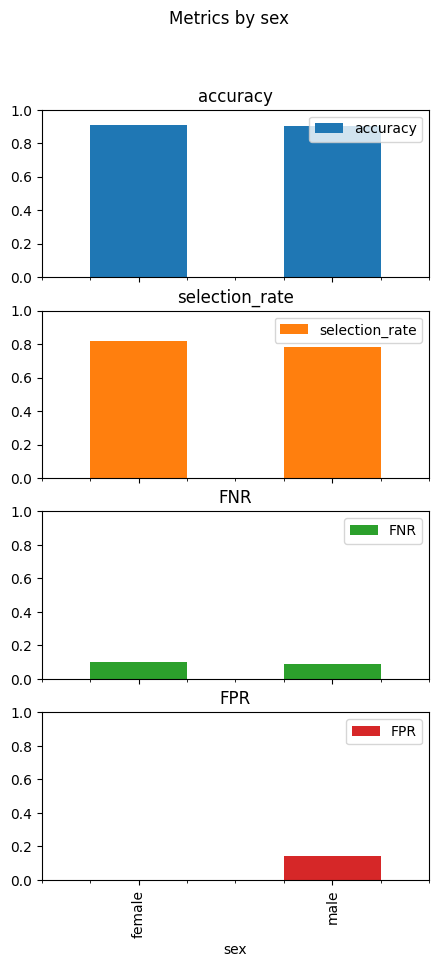

In [147]:
# Fairness report for `sex` (uses labels for readability)
fairness_report(X_test['sex'], feature_name='sex', group_labels={0: 'female', 1: 'male'})

### Observations from Fairness metrics for sensitive attribute - 'sex'

The model appears to show minor disparities in terms of fairness between male and female groups.

#### Key Observations

* **Demographic Parity**: The model demonstrates very close selection rates between groups. Females have a slightly higher selection rate (82.0%) compared to males (78.1%), resulting in a small demographic parity difference of 0.0397 (3.97 percentage points). The demographic parity ratio of 0.95 is generally considered acceptable in most fairness frameworks (typically ratios above 0.8 are deemed fair).
* **Predictive Performance**: Both groups achieve high and comparable accuracy (approximately 92% for females and 90% for males), suggesting the model performs well for both demographics without significant performance degradation for either group.
* **Error Rates**: The model exhibits very low false negative rates (FNR) for both groups (~10%), indicating it rarely fails to identify qualified candidates. However, there is a notable disparity in false positive rates (FPR), with males experiencing a substantially higher FPR (~15%) compared to females (near 0%). This suggests the model is more prone to incorrectly predicting passing outcomes for male students who actually fail.

#### Conclusion
While demographic parity is nearly satisfied, the FPR disparity raises concerns about equalized odds. The model may be over-predicting success for males, which could lead to inappropriate resource allocation or unrealistic expectations for this group.
The primary area for improvement is reducing the FPR disparity to achieve better equalized odds across both groups.


 Running Multiple Data Splits With Model Seed Constant
----------------------------------------------------------------------------------------------------
Seed: 276
Seed: 143
Seed: 148
Seed: 270
Seed: 737


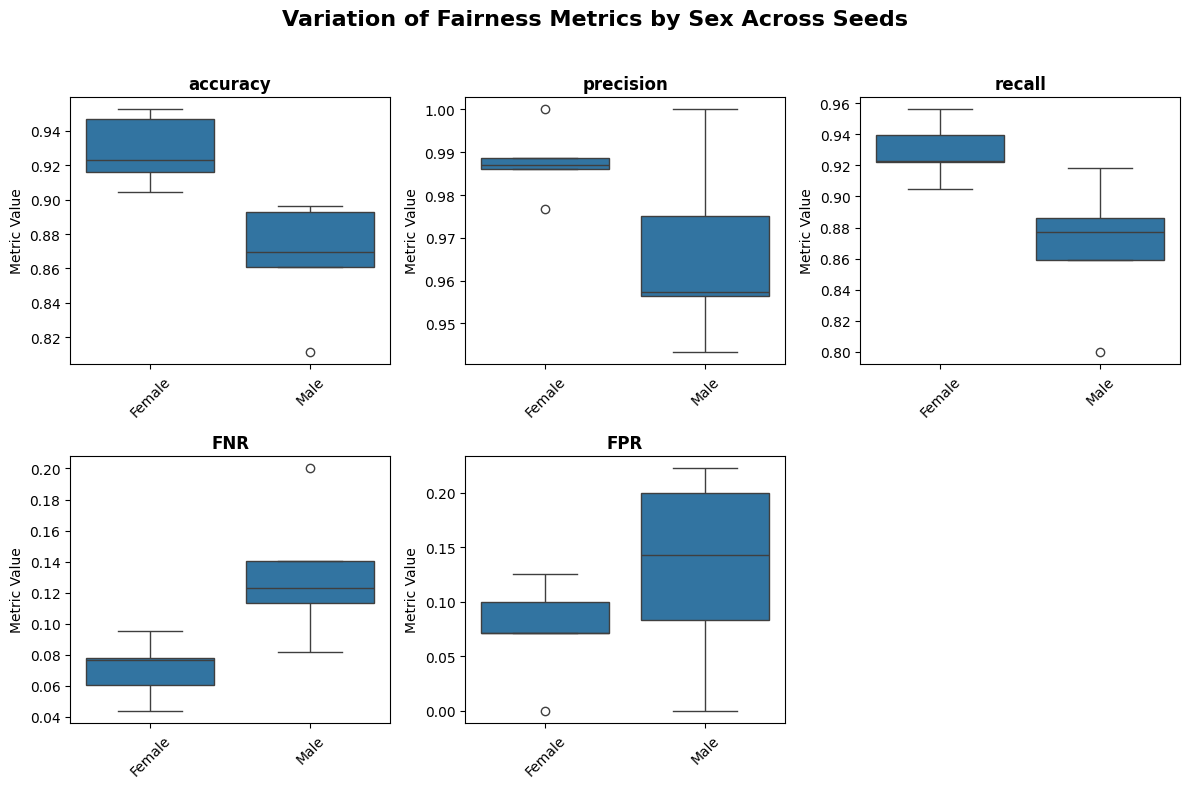

In [148]:
results_fairness_sex, results_diff_sex = stability_pipeline(seeds, "sex")
fig2, axes2 = plot_fairness_variation(
    results_fairness_sex,
    sensitive_feature_name='sex',
    group_mapping={0: 'Female', 1: 'Male'}  # Adjust based on your encoding
)
plt.show()

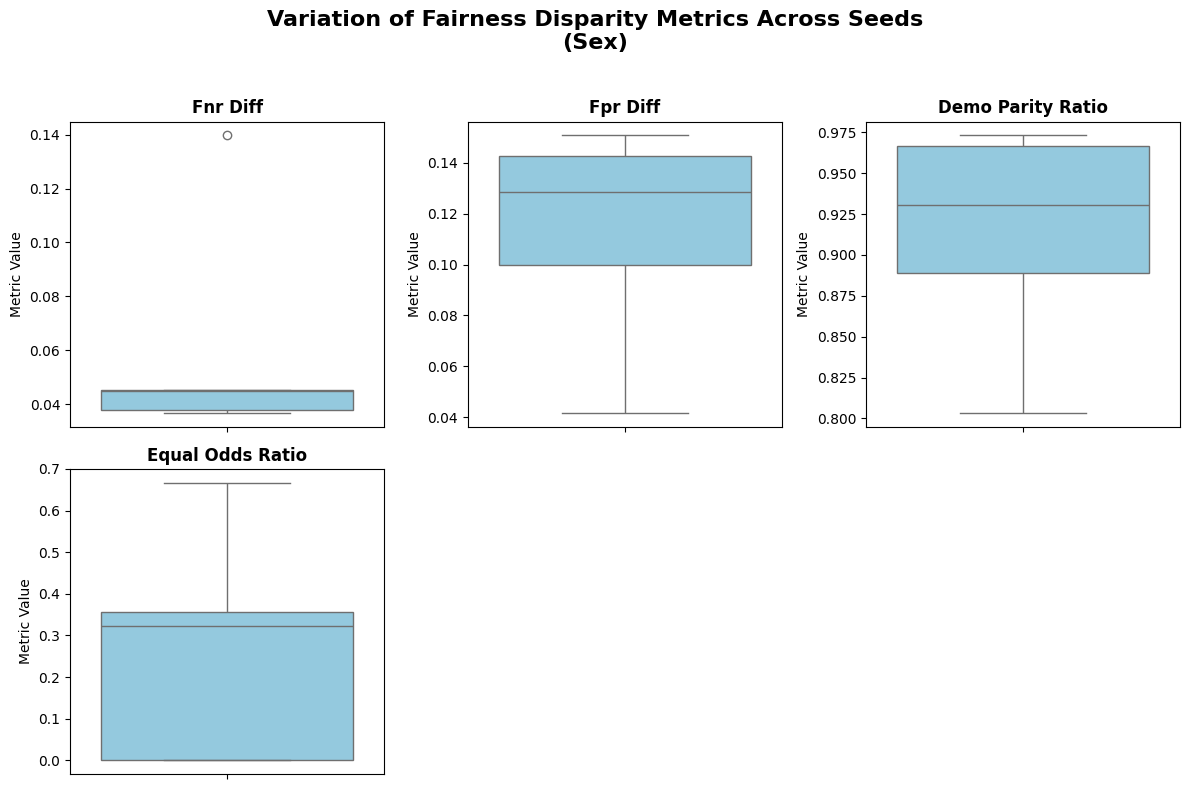

In [149]:
fig2, axes2 = plot_fairness_differences(
    results_diff_sex,
    sensitive_feature_name='sex'
)
plt.show()

### Fairness Audit Summary: Student's sex

The model demonstrates reasonable stability in fairness metrics across different train-test splits, though some concerning patterns emerge regarding equalized odds and error rate disparities.

#### Key Observations:

* **Demographic Parity**: The demographic parity ratio remains consistently high across all seeds (median ~0.93), indicating stable and near-fair selection rates between male and female groups.
* **Predictive Performance**: Females consistently achieve higher accuracy (median ~0.92) compared to males (median ~0.87) across all seeds. Similarly, females maintain consistently higher precision and recall, indicating the model is more reliable for female predictions.
* **Error Rate Disparities**:Males experience consistently higher FNR (median ~0.14) compared to females (median ~0.07), double the rate. This means the model more frequently fails to identify qualified male students. However, the most significant disparity exists in FPR, where males show substantially higher rates (median ~0.14) compared to females (median ~0.09). The FPR difference is consistently around 0.10-0.14 across seeds, with minimal overlap between distributions.
* **Equalized Odds**: The equal odds ratio shows extremely poor performance (median ~0.35, range 0.0-0.67), indicating severe violations of equalized odds fairness. This metric combines both FPR and FNR disparities, and the consistently low values across all seeds confirm that the model systematically treats male and female students differently in terms of error patterns.

#### Conclusion
While the consistency across seeds demonstrates that these fairness issues are not due to random data splitting,rather these are either pre-existing or systematic and reproducible. While the model performs accurately for female group, it the higher error rates for male is concerning. This implies that the model will more relatively more likely to fail an actually passing male student and pass an actually failing male student compared to their female counterpart. 
The persistent FPR and equal odds violations require immediate attention through bias mitigation techniques
Applying threshold optimization separately for each group or implementing fairness-aware training methods can help improve these metrics. 

#### Sensitive Attribute as 'age'

Demographic parity difference: 0.2857
Demographic parity ratio: 0.7143
15 selection rate: 0.8800
16 selection rate: 0.8333
17 selection rate: 0.7561
18 selection rate: 0.7143
19 selection rate: 1.0000


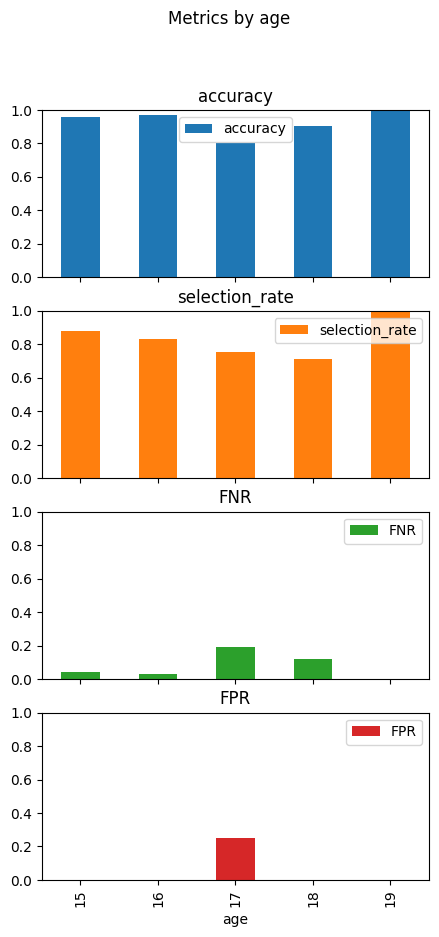

In [150]:
# Fairness report for `age`
fairness_report(X_test['age'], feature_name='age')

### Fairness Audit Summary: Student's Age

The model demonstrates significant age-based disparities, with much larger fairness violations compared to the sex-based analysis. 

#### Key Observations:
* **Demographic Parity**: The model shows considerable disparity in selection rates across age groups, with a demographic parity ratio of 0.71, well below the commonly accepted fairness threshold of 0.8. Selection rates vary substantially from 71.4% (age 18) to 100% (age 19), with younger students (15-16) receiving higher selection rates (~88% and 83%) compared to middle-range students (17-18) who face lower rates (~76% and 71%).
* **Predictive Performance**: Accuracy varies considerably across age groups, ranging from approximately 80% to nearly 100%. Ages 15, 16, and 19 achieve very high accuracy (~95-100%), while ages 17 and 18 experience notably lower accuracy (~80% and 93% respectively). This suggests the model is less reliable for students aged 17-18, potentially due to insufficient training data or more complex prediction patterns for these age groups.
* **Error Rates**: The most significant disparity occurs at age 17, which experiences an FNR of approximately 20% which is much higher than other age groups. This indicates the model disproportionately fails qualified 17-year-old students. Similaryly, age 17 also shows the highest FPR (~25%), meaning the model frequently over-predicts success for this age group. Other ages maintain very low or zero FPR.

#### Conclusion
Students aged 17 are systematically disadvantaged by the model, experiencing both the lowest selection rate (75.6%), lowest accuracy (~80%), highest FNR (~20%), and highest FPR (~25%). Since their isn't a data quality issues as their are students aged 17 has highest count in training data, there appears to be a genuine difficulty in predicting outcomes for this transitional age group. The 28.57 percentage point gap in selection rates represents a meaningful fairness violation that could have significant real-world consequences, particularly for 17-18 year old students.

The recommendation here would be to create an age-specific model calibration or stratified training approaches. Additionally, it should be examined whether age interacts with other features in ways that disadvantage certain groups. Finally, implementing bias mitigation strategies specifically targeting age-based disparities can help improve the performance of the model for the fairness metrics for this age group. 

#### Sensitive Attribute as 'Fedu_none'

Demographic parity difference: 0.1938
Demographic parity ratio: 0.8062
Fedu Not None selection rate: 0.8062
Fedu None selection rate: 1.0000


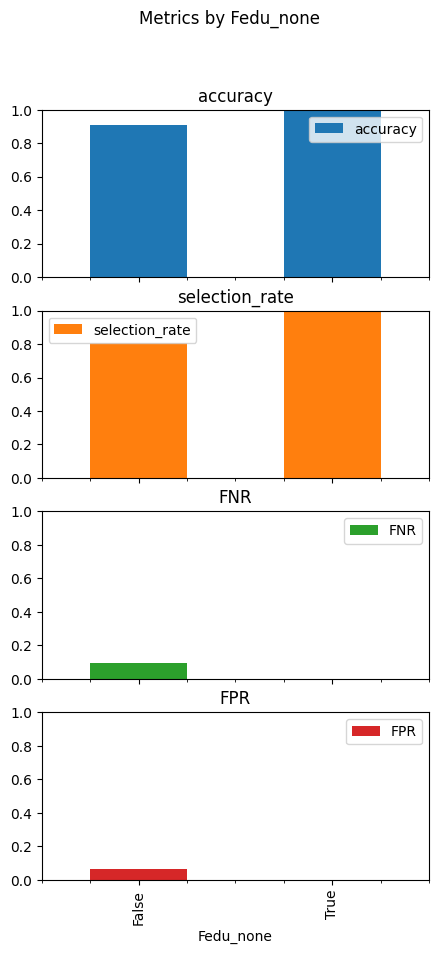

In [151]:
# Fairness report for `Fedu_none`
fairness_report(
    X_test['Fedu_none'],
    feature_name='Fedu_none',
    group_labels={1: 'Fedu None', 0: 'Fedu Not None'}
)

#### Sensitive Attribute as 'Medu'

Demographic parity difference: 0.0595
Demographic parity ratio: 0.9265
Medu Not None selection rate: 0.8095
Medu None selection rate: 0.7500


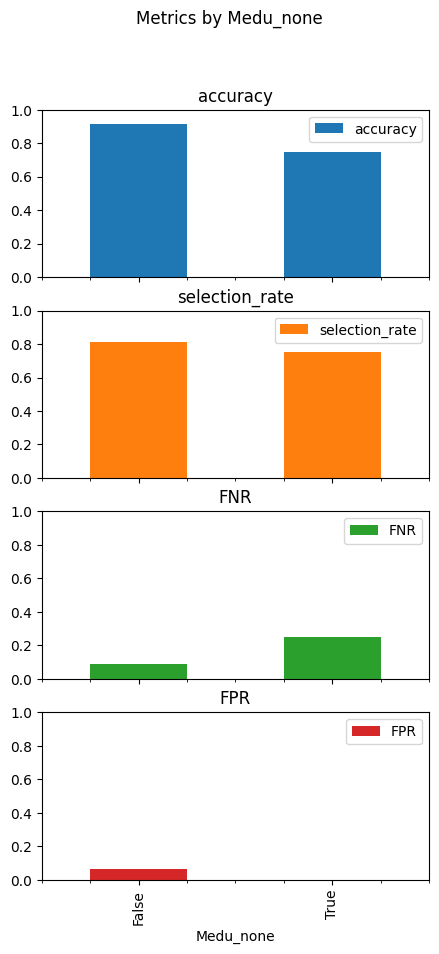

In [152]:
# Fairness report for `Medu_none`
fairness_report(
    X_test['Medu_none'],
    feature_name='Medu_none',
    group_labels={1: 'Medu None', 0: 'Medu Not None'}
)

### Fairness Audit Summary: Parental Education Level
The motivation behind this analysis was to see if the model is biased against families with socioeconomic disadvantages, like families where parents haven't received any education or where parents are unemployed.

* **Initial Hypothesis**: The model might exhibit unfair predictions against students whose parents (father or mother) have not received formal education, potentially perpetuating socioeconomic disadvantages.

#### Key Observations:
* **Demographic Parity**: Father's education shows a demographic parity ratio of 0.81 with students whose fathers lack education receiving a higher selection rate (100% vs. 80.6%)—contrary to expectations. In contrast, mother's education shows better parity (ratio of 0.93) but aligns with the hypothesis, where students whose mothers lack education receive a lower selection rate (75.0% vs. 81.0%). The father's education pattern represents an unexpected reverse bias.
* **Predictive Performance**: Accuracy varies significantly by parental education status. Students whose fathers lack education achieve high accuracy (~97%), while those whose mothers lack education experience lower accuracy (~76% vs. ~92%). This 16-percentage-point gap for maternal education suggests the model struggles more with predictions when mothers have no formal schooling.
* **Error Rates**: The most concerning finding relates to mother's education, i.e. students whose mothers lack education experience substantially higher false negative rates (~25% vs. ~10%), meaning the model is 2.5 times more likely to incorrectly predict they will fail when they would actually pass. Father's education shows minimal error rates across both groups. False positive rates remain consistently low (~7-8%) regardless of parental education status.

### Conclusion
The initial hypothesis is contradicted for father's education but supported for mother's education. This asymmetry suggests maternal and paternal education interact differently with the model's prediction mechanisms.
However, since the sample size of students with either mother (only 6) or father  (only 7) lacking education experience is very small compared to their counterpart, the test-training split of the data can heavily impact this outcome. Therefore, more training data from this category is required to concretely conclude the aforementioned hypothesis. 

#### Sensitive Attribute as 'Fjob_at_home'

Demographic parity difference: 0.4007
Demographic parity ratio: 0.5168
False selection rate: 0.8293
True selection rate: 0.4286


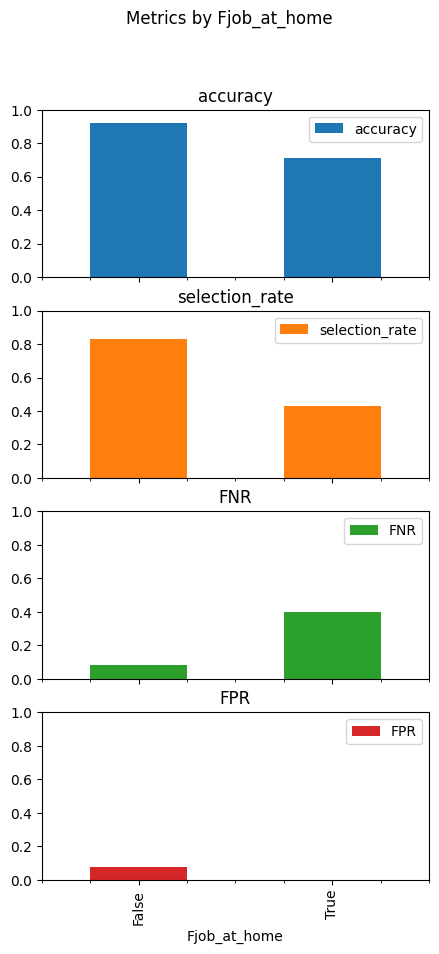

In [153]:
# Fairness report for `Fjob_at_home`
fairness_report(
    X_test['Fjob_at_home'],
    feature_name='Fjob_at_home'
)

Demographic parity difference: 0.0590
Demographic parity ratio: 0.9312
False selection rate: 0.7982
True selection rate: 0.8571


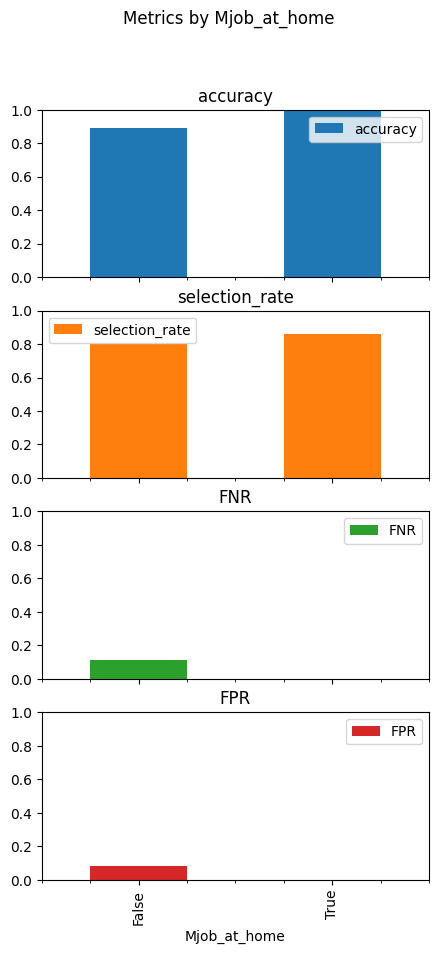

In [154]:
# Fairness report for `Mjob_at_home`
fairness_report(
    X_test['Mjob_at_home'],
    feature_name='Mjob_at_home'
)

### Fairness Audit Summary: Parental Employment Status

**Initial Hypothesis**: The model might exhibit unfair predictions against students whose parents (father or mother) are unemployed or work from home, potentially disadvantaging students from economically vulnerable households.

#### Key Observations
* **Demographic Parity**: Father's employment shows a severe fairness violation with a demographic parity ratio of only 0.52, well below the 0.8 threshold, with a difference of 40.07 percentage points. Students whose fathers work at home receive dramatically lower selection rates (42.9% vs. 82.9%), representing the most substantial bias observed across all protected attributes analyzed. In contrast, mother's employment demonstrates good parity (ratio of 0.93) with minimal disparity, where students whose mothers work at home actually receive slightly higher selection rates (85.7% vs. 79.8%).
* **Predictive Performance**: The accuracy gap is similar to the selection rate pattern. Students whose fathers work at home experience significantly lower accuracy (~71% vs. ~92%). Mother's employment shows comparable accuracy across both groups (~90% and ~82%), with much smaller performance differences.
* **Error Rates**: Students whose fathers work at home face dramatically elevated false negative rates (~40% vs. ~10%)—four times higher than their counterparts—meaning the model frequently fails to identify qualified students from this group. Mother's employment shows minimal FNR differences (~12% for both groups). False positive rates remain low and similar across all groups (~8-10%).

### Conclusion
The initial hypothesis is strongly confirmed for father's employment, i.e., students whose fathers are unemployed face severe disadvantage, while it is not supported for mother's employment. 
The disparity for father's employment bias needs to be remediated through targeted model retraining, bias mitigation techniques, or separate calibration for this vulnerable group.

## SHAP Analysis

In [155]:
#Import the SHAP Library
import shap
import tqdm as notebook_tqdm

In [156]:
# Initialize the explainer
explainer = shap.LinearExplainer(lasso_model, X_train, feature_perturbation="interventional")
# Apply it to the test data
shap_values = explainer.shap_values(X_test)

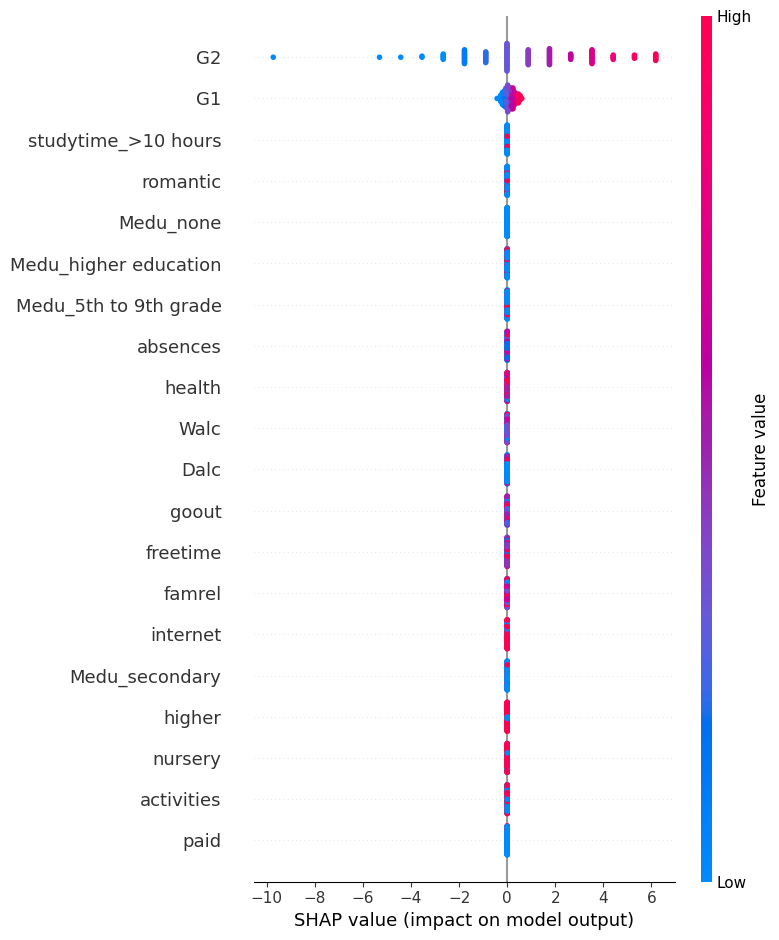

In [157]:
#Clean Up Values Before Passing to the Summary Plot

X_test_clean = X_test.astype(float).values
shap_values_clean = shap_values.astype(float)

#Plot Shap Summary Plot
shap.summary_plot(shap_values_clean, X_test_clean, feature_names=X_train.columns)

In [158]:
#Print Shap Plot to Visualise Which Features Pushed The Prediction Which Way
shap.initjs()
idx = 1
print("Pass" if y_test.iloc[idx] else "Fail")
print(X_test_clean[idx])
shap.force_plot(
    explainer.expected_value, shap_values_clean[idx,:], X_test_clean[idx,:],
    feature_names=X_train.columns
)

Pass
[ 0.  0. 16.  1.  0.  0.  0.  0.  1.  0.  0.  1.  1.  1.  0.  2.  3.  3.
  2.  2.  4.  2. 11. 11.  0.  0.  0.  0.  1.  0.  0.  0.  1.  0.  0.  0.
  0.  1.  0.  0.  0.  1.  0.  0.  1.  0.  0.  0.  0.  1.  0.  0.  0.  1.
  0.  1.  0.  0.  0.]


In [159]:
#Print the SHAP Values of The Features That Pushed The Prediction Higher (Positive SHAP Values)
shap_row = shap_values_clean[idx]

positive_features = {
    feature: value
    for feature, value in zip(X_train.columns, shap_row)
    if value > 0
}

print("Positive SHAP features for sample", idx)
for f, v in positive_features.items():
    print(f"{f}: {v}")


Positive SHAP features for sample 1
G1: 0.020565078180411134


In [160]:
#Print the SHAP Values of The Features That Pushed The Prediction Lower (Negative SHAP Values)
shap_row = shap_values_clean[idx]

negative_features = {
    feature: value
    for feature, value in zip(X_train.columns, shap_row)
    if value < 0
}

print("Negative SHAP features for sample", idx)
for f, v in negative_features.items():
    print(f"{f}: {v}")


Negative SHAP features for sample 1
G2: -0.00883987726758686


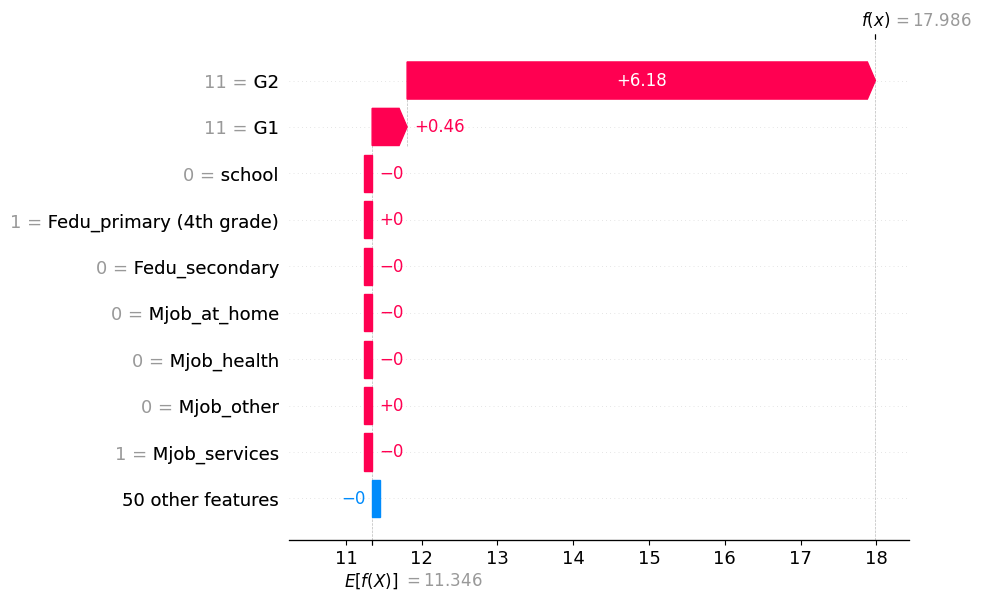

In [161]:
shap_exp = shap.Explanation(
    values=shap_values_clean[0],
    base_values=explainer.expected_value,
    data=X_test_clean[idx],
    feature_names=X_train.columns
)

# Waterfall plot
shap.plots.waterfall(shap_exp)

# Appendix

* [1] https://archive.ics.uci.edu/dataset/320/student+performance
* [2] https://joshuagans.substack.com/p/the-covid-19-grading-mess
* [3] https://www.kaggle.com/code/mohamedsalahibrahim/student-performance
* [4] https://archive.ics.uci.edu/dataset/320/student+performance